# Pytorch computer vision

See reference notebook: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/03_pytorch_computer_vision.ipynb

See reference online book: https://www.learnpytorch.io/03_pytorch_computer_vision/

ibm: https://www.ibm.com/think/topics/convolutional-neural-networks#763338460

## What we're going to cover 

- Getting a vision dataset to work with using torch vision.dataset.
- Architecture of a **convolutional neural neural network(CNN)** with Pytorch.
- An end-to-end multi-class image classification problem.
- Steps in modelling with **CNNs in PyTorch** :
  - Creating a CNN model with PyTorch.
  - Picking a loss and optimizer
  - Training a model 
  - Evaluating a model

## What is a convolutional neural network(CNN)

![alt text](source/03-cnn.png)

## 0. Computer vision libraries in PyTorch

`torchvision.datasets` - get datasets and data loading functions for computer vision here.

`torchvision.models` - get pretrained computer vision models that you can leverage for your own problems.

`torchvision.transforms` - functions for manipulating your vision data(images) to be suitable for use with an ML model.

`torch.utils.data.Dataset` - Base dataset class for PyTorch.

`torch.utils.data.DataLoader` -  Creates a Python iterable over a dataset.

In [1]:
# Import PyTorch
import torch
import torch.nn as nn

# Import torchvision
import torchvision
from torchvision import datasets, transforms
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


## 1. Getting a dataset

The dataset we'll be using is FashionMNIST from torchvision.dataset - 

https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html

![alt text](source/03-Fashion-MNIST-dataset-cover.png)

In [2]:
# Setup training data
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root = "data", # where to download data to?
    train = True, # do we want the training dataset?
    download = True, # do we want to download yes/no?
    transform = torchvision.transforms.ToTensor(), # how do we want to transform the data?
    target_transform = None # how do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.9MB/s]


Trainsforms to tensor - 
https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names = train_data.classes

class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
classes_to_idx = train_data.class_to_idx
classes_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### 1.1 Check input and output shapes of data

In [7]:
# Check the shape of our image
print(f"Image shape: [Color_channels, height, width] -> {image.shape} ")
print(f"Image label: {class_names[label]}")

Image shape: [Color_channels, height, width] -> torch.Size([1, 28, 28]) 
Image label: Ankle boot


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

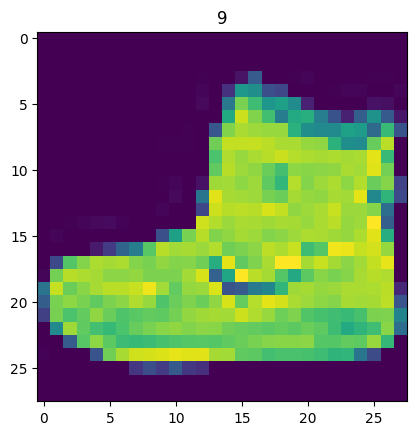

In [8]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)
# image 

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

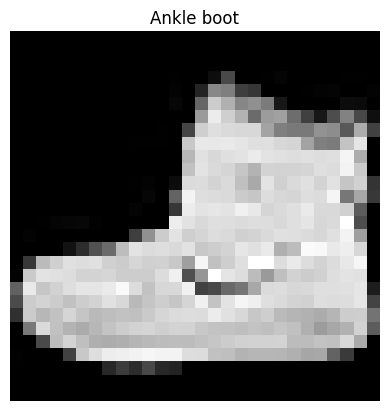

In [9]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

Do you think these items of clothing(images) could be modelled with pure linear lines? Or do you think we'll need non-linearities?

In [10]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now, our data is in the form of Pytorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batcher (or mini-batches).

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may not be able to look(store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32).

2. It gives our neural network more chances to update its gradients per epoch.

In [11]:
from torch.utils.data import DataLoader

# Set up the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterable DataLoaders
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

test_dataloader, train_dataloader

print(f"DataLoader: {train_dataloader, test_dataloader}")
print(f"Length of training dataloader: {len(train_dataloader)} batches of {BATCH_SIZE} samples")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE} samples")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x79202c326ea0>, <torch.utils.data.dataloader.DataLoader object at 0x79202c31c920>)
Length of training dataloader: 1875 batches of 32 samples
Length of test dataloader: 313 batches of 32 samples


In [12]:
# Check out what inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28])
Label: 0, label size: torch.Size([]), class name: T-shirt/top


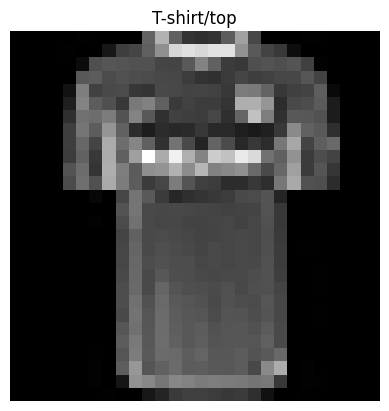

In [13]:
# Show a sample 
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

print(f"Image shape: {img.shape}")
print(f"Label: {label}, label size: {label.shape}, class name: {class_names[label]}")

## 3. Model 0: Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best practice to start with a baseline model.

A baseline model is simple model you will try and improve upon with subsequent models/experiments.

In other words: start simply and add complexity when necessary.

In [14]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a sample image
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # performs a forward pass of the sample through the flatten layer

# Print out what happened
print(f"Original shape: {x.shape} -> [Color_channels, height, width]")
print(f"Flattened shape: {output.shape} -> [Color_channels * height * width]")

Original shape: torch.Size([1, 28, 28]) -> [Color_channels, height, width]
Flattened shape: torch.Size([1, 784]) -> [Color_channels * height * width]


In [15]:
from torch import nn
# Create a flatten layer
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [16]:
torch.manual_seed(42)

# Setup model with input and output size
model_0 = FashionMNISTModelV0(input_shape=28 * 28, 
                              hidden_units=10, 
                              output_shape=len(class_names)).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

dummy_x = torch.rand(1, 1, 28, 28) # create a random tensor with the same shape as a single image
model_0(dummy_x).shape # pass the random tensor through the model and check the output shape

In [17]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`

* Optimizer - our optimizer `torch.optim.SGD()` (stochastic gradient descent)

* Evaluation metric - since we're working on a classification problem, let's use accruacy as our evaluation metric.

In [18]:
import requests
import base64
from pathlib import Path 

# Download helper functions from Learn PyTorch repo(if it's not already downloaded)
if Path("ml_helper_functions.py").is_file():
    print("ml_helper_functions.py already exists, skipping download.")
else:
    print("Downloading ml_helper_functions.py...")
    url = "https://raw.githubusercontent.com/LiuAoran/lar_ml_helpers/refs/heads/main/ml_helper_functions.py"
    request = requests.get(url)
    with open("ml_helper_functions.py", "wb") as f:
        f.write(request.content)
        print("ml_helper_functions.py downloaded successfully.")

ml_helper_functions.py downloaded successfully.


In [19]:
# import accuracy metric helper function
from ml_helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### 3.2 Creating a function to time our experiments

Machine learning is very experimental.

Two of the main things you'll often want to track are:

1. Model's Performance (loss and accuracy values etc.)

2. How fast it runs

In [20]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = "cpu"): # type: ignore
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [21]:
start_time = timer()

# Some Code to train the model would go here...

end_time = timer()

print_train_time(start_time, end_time, device = "cpu") # type: ignore

Train time on cpu: 0.000 seconds


2.888200003781094e-05

> UPTOHERE 3.3 Creating a training loop and training a model on batches of data...
>
> Highlight that the optimizer will update a model's parameters once per batch rather than once per epoch...

## 3.3 Creating a training loop and training a model on batches of data

1. Loop throught epochs.

2. Loop through training batches, perform training steps, calculate the train loss *per batch* .

3. Loop through testing batches, perform testing steps, calculate the test loss per batch.

4. Print out what's happening.

5. Time it all (for run).

In [22]:
# impport tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed for reproducibility
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Check the model's device
print(f"Model is on: {next(model_0.parameters()).device}")

# Set the number of epochs (how many times the model will look at the data)
epochs = 3

# Create a training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")

    # Training
    train_loss = 0

    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train() 

        y_pred = model_0(X) # Do the forward pass

        loss = loss_fn(y_pred, y) # Calculate the loss
        train_loss += loss.item() # add the loss to the total training loss

        optimizer.zero_grad() # Optimizer zero grad

        loss.backward() # Loss backward

        optimizer.step() # Optimizer step

        #Print out what's happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")  # type: ignore

    # Testing
    test_loss, test_acc = 0, 0
    model_0.eval() # Put model in evaluation mode
    with torch.inference_mode(): # Turn on inference mode (turns off gradients)
        for X_test, y_test in test_dataloader:

            # 1. Forward pass
            test_pred = model_0(X_test)

            # 2. Calculate loss(accumulatively)
            test_loss += loss_fn(test_pred, y_test).item()
        
            # 3. Calculate accuracy(accumulatively)
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        # Calculate the average loss and accuracy per batch
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
    
    # Print out what's happening
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
train_time_on_cpu_model_0 = print_train_time(train_time_start_on_cpu, train_time_end_on_cpu, device=str(next(model_0.parameters()).device)) # type: ignore
            

Model is on: cpu


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 1106.97954 | Test loss: 0.50954 | Test accuracy: 82.04%

Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 893.12278 | Test loss: 0.47989 | Test accuracy: 83.20%

Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 853.18760 | Test loss: 0.47664 | Test accuracy: 83.43%

Train time on cpu: 26.817 seconds


## 4. Make predictions and get Model 0 result

In [23]:
torch.manual_seed(42)

def evaluate_model(model: torch.nn.Module, 
                   data_loader: torch.utils.data.DataLoader, 
                   loss_fn: torch.nn.Module, accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader."""
    loss, acc = 0, 0
    model.eval() # Put model in evaluation mode
    with torch.inference_mode(): # Turn on inference mode (turns off gradients)
        for X, y in data_loader:
            # Make sure the model is on the right device
            X, y = X.to(next(model.parameters()).device), y.to(next(model.parameters()).device)
            # 1. Forward pass
            y_pred = model(X)

            # 2. Calculate loss(accumulatively)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Scale loss and accuracy per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
    
    return {"model_name": model.__class__.__name__, 
            "model_loss": loss.item(),  
            "model_acc": acc}

# Calculate the results of model_0 on the test dataset
model_0_results = evaluate_model(model=model_0,
                               data_loader=test_dataloader,
                               loss_fn=loss_fn,
                               accuracy_fn=accuracy_fn)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## 5. Setup device agnostic-code (for using a GPU if there is one)

In [24]:
!nvidia-smi

Mon Jun 29 09:27:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
import torch
import torch.nn as nn
torch.cuda.is_available()
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

We learned about the power of non-linearity in notebook 02 - https://github.com/LiuAoran/freecodecamp-machine-learning-notes/blob/main/02_pytorch_classification_video.ipynb

In [26]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, 
                 input_shape: int, 
                 hidden_units: int, 
                 output_shape: int):
         super().__init__()
         self.layer_stack = nn.Sequential(
             nn.Flatten(), # Flatten the input image into a single vector
             nn.Linear(in_features=input_shape, out_features=hidden_units),
             nn.ReLU(),
             nn.Linear(in_features=hidden_units, out_features=output_shape),
             nn.ReLU()
         )
         
    def forward(self, x):
        return self.layer_stack(x)

In [27]:
# Create a model instance and send it to the target device
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=28*28,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer and evaluation metrics

In [28]:
from ml_helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

## 6.2 Functionizing training and evaluation/testing loops

Let's create a function for:

- training loop - `train_step()`

- testing loop - `test_step()`

In [29]:
def train_step(
    model: torch.nn.Module, 
    data_loader: torch.utils.data.DataLoader, 
    loss_fn: torch.nn.Module, 
    optimizer: torch.optim.Optimizer, 
    accuracy_fn,
    device: torch.device = device # type: ignore
):
    """Performs a training step with the 
    given model, data loader, loss function, optimizer, and accuracy function."""
    ### Training Step ###
    train_loss, train_acc = 0, 0
    # Put the model in training mode
    model.train()
    
    for batch, (X, y) in enumerate(data_loader):

        X, y = X.to(device), y.to(device)

        y_pred = model(X) # Do the forward pass (Outputs the raw logits from the model)

        loss = loss_fn(y_pred, y) # Calculate the loss
        train_loss += loss.item() # add the loss to the total training loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # go from logits -> predicted labels

        optimizer.zero_grad() # Optimizer zero grad

        loss.backward() # Loss backward

        optimizer.step() # Optimizer step

        #Print out what's happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(data_loader.dataset)} samples.")  # type: ignore

    # Devide the total training loss and accuracy by the number of batches
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    

In [30]:
def test_step(
    model: torch.nn.Module, 
    data_loader: torch.utils.data.DataLoader, 
    loss_fn: torch.nn.Module, 
    accuracy_fn,
    device: torch.device = device # type: ignore
):
    """Performs a testing step with the given model, data loader, loss function, and accuracy function."""
    ### Testing Step ###
    test_loss, test_acc = 0, 0
    # Put the model in evaluation mode
    model.eval()
    
    with torch.inference_mode(): # Turn on inference mode (turns off gradients)
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)

            test_pred = model(X) # Do the forward pass

            loss = loss_fn(test_pred, y) # Calculate the loss
            test_loss += loss.item() # add the loss to the total test loss
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) # go from logits -> predicted labels

        # Devide the total test loss and accuracy by the number of batches
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

In [31]:
torch.manual_seed(42)

# Measure the time it takes to train and test the model on the CPU
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

# Set epochs
epochs = 3

# Create a optimization and evaluation loop using the train_step() and test_step() functions
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device) # type: ignore
    
    test_step(model=model_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device) # type: ignore
    
train_time_end_on_gpu = timer()
train_time_on_gpu_model_1 = print_train_time(train_time_start_on_gpu, train_time_end_on_gpu, device=device) # type: ignore
    

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 1.09199 | Train accuracy: 61.34%
Test loss: 0.95637 | Test accuracy: 65.00%
Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.78101 | Train accuracy: 71.93%
Test loss: 0.72227 | Test accuracy: 73.91%
Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.67027 | Train accuracy: 75.94%
Test loss: 0.68500 | Test accuracy: 75.02%
Train time on cuda: 30.397 seconds


In [32]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

> **Note:** Sometimes depending on your data/hardware, you might find that your model trains faster on CPU than GPU.
>
> Why is this?
> 
> 1. It could be that the overhead for copying data/model to and from the GPU overweights the compute benefits offered by the GPU.
>
> 2. The hardware you're using has a better CPU in terms compute capability than the GPU. 
>
> Making Deep Learning Go Brrrr From First Principles:
>
> https://horace.io/brrr_intro.html


In [33]:
# Train time on CPU for model_0
train_time_on_cpu_model_0

26.816706615999976

In [34]:
model_1_results = evaluate_model(model=model_1,
                               data_loader=test_dataloader, 
                               loss_fn=loss_fn,
                               accuracy_fn=accuracy_fn)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

## Model 2: Build a Convolutional Neural Network (CNN)

CNNs Are also known ConvNets.

CNN's are known for their Capabilities o find patterns in vision data.

To find out what's happen inside in CNN, see the websize: https://poloclub.github.io/cnn-explainer/ 



In [35]:
# Create a model with non-linear and linear layers
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture that replicates tiny VGG (Visual Geometry Group) model.
    model from CNN explainer website: https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, 
                 input_shape: int, 
                 hidden_units: int, 
                 output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
             nn.Conv2d(in_channels=1, 
                       out_channels=hidden_units, 
                       kernel_size=3, 
                       stride=1, 
                       padding=1), 
             # Values we can set ourselfs in our NN's are called hyperparameters, the values we can't set ourselves are called parameters
             nn.ReLU(),
             nn.Conv2d(in_channels=hidden_units, 
                       out_channels=hidden_units, 
                       kernel_size=3, 
                       stride=1, 
                       padding=1),
             nn.ReLU(),
             nn.MaxPool2d(kernel_size=2, stride=2)
        )
         
        self.conv_block_2 = nn.Sequential(
             nn.Conv2d(in_channels=hidden_units, 
                       out_channels=hidden_units, 
                       kernel_size=3, 
                       stride=1, 
                       padding=1),
             nn.ReLU(),
             nn.Conv2d(in_channels=hidden_units, 
                       out_channels=hidden_units, 
                       kernel_size=3, 
                       stride=1, 
                       padding=1),
             nn.ReLU(),
             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
             nn.Flatten(),
             nn.Linear(in_features=hidden_units * 7 * 7, # The input features to the linear layer is the number of channels * the height * the width of the output from the previous conv block 
                       out_features=output_shape)
        )

    def forward(self, x):
         x = self.conv_block_1(x)
         # print(f"Shape after conv_block_1: {x.shape}")
         x = self.conv_block_2(x)
         # print(f"Shape after conv_block_2: {x.shape}")
         x = self.classifier(x)
         return x


In [36]:
torch.manual_seed(42)
# Create a model with non-linear and linear layers
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [37]:
rand_image_tensor = torch.randn(size=(1, 28, 28)).to(device)
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [38]:
model_2(rand_image_tensor.unsqueeze(0)).to(device)

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

### Stepping through `nn.Conv2d()`

See documentation:

https://docs.pytorch.org/docs/2.12/generated/torch.nn.Conv2d.html

In [39]:
torch.manual_seed(42)

images = torch.randn(size = (32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image shape: {test_image.shape}")
print(f"Test image: \n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image shape: torch.Size([3, 64, 64])
Test image: 
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,

In [40]:
# Create a single convolutional layer
conv_layer = nn.Conv2d(in_channels=3, # input channels
                       out_channels=10, # output channels
                       kernel_size= 3, # size of the kernel/filter
                       stride= 1, # how many pixels the kernel moves at a time
                       padding= 0) # how many pixels to pad the input image with

conv_output = conv_layer(test_image.unsqueeze(0)) # unsqueeze adds a batch dimension to the image
conv_output.shape
conv_output

tensor([[[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
            6.6224e-01, -2.3216e-01],
          [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
           -1.8552e-01, -5.7622e-01],
          [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
            1.4923e-01,  1.4236e-01],
          ...,
          [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
            4.2594e-01, -4.8341e-01],
          [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
           -3.6626e-01,  3.5645e-01],
          [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
           -4.9680e-01, -7.2258e-01]],

         [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
           -1.7643e+00,  2.5263e-01],
          [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
            4.8068e-01,  8.4869e-01],
          [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
            2.4611e-01,  6.6233e-01],
          ...,
     

In [41]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

In [42]:
torch.__version__

'2.11.0+cu128'

### 7.2 Stepping with `nn.MaxPool2d()`

See documentation: 

https://docs.pytorch.org/docs/2.12/generated/torch.nn.MaxPool2d.html

In [43]:
test_image.shape

torch.Size([3, 64, 64])

In [44]:
# Print out original image shape without unsqueezed dimension

print(f"Original image shape: {test_image.shape} -> [Color_channels, height, width]")
print(f"Test image with batch dimension shape: {test_image.unsqueeze(0).shape} -> [Batch_size, Color_channels, height, width]")

# Create a sample MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after conv_layer: {test_image_conv.shape} -> [Batch_size, Color_channels, height, width]")

# Pass data through the max_pool_layer
test_image_max_pool = max_pool_layer(test_image_conv)
print(f"Shape after max_pool_layer: {test_image_max_pool.shape} -> [Batch_size, Color_channels, height, width]")

Original image shape: torch.Size([3, 64, 64]) -> [Color_channels, height, width]
Test image with batch dimension shape: torch.Size([1, 3, 64, 64]) -> [Batch_size, Color_channels, height, width]
Shape after conv_layer: torch.Size([1, 10, 62, 62]) -> [Batch_size, Color_channels, height, width]
Shape after max_pool_layer: torch.Size([1, 10, 31, 31]) -> [Batch_size, Color_channels, height, width]


In [45]:
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))

# Create a sample MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through the max_pool_layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f"max_pool_layer input: \n {random_tensor} \n")
print(f"max_pool_layer input shape: {random_tensor.shape} -> [Batch_size, Color_channels, height, width]")
print(f"max_pool_layer output: \n {max_pool_tensor} \n")
print(f"max_pool_layer output shape: {max_pool_tensor.shape} -> [Batch_size, Color_channels, height, width]")


max_pool_layer input: 
 tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]]) 

max_pool_layer input shape: torch.Size([1, 1, 2, 2]) -> [Batch_size, Color_channels, height, width]
max_pool_layer output: 
 tensor([[[[0.3367]]]]) 

max_pool_layer output shape: torch.Size([1, 1, 1, 1]) -> [Batch_size, Color_channels, height, width]


## 7.3 Setup loss function and optimizer for model_2

In [46]:
# Setup loss function and optimizer for model_2
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

## Training and testing model_2 using our training and test functions

In [47]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure the time it takes to train and test the model on the GPU
from timeit import default_timer as timer
train_time_start_2 = timer()

# train the model on the GPU
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device) # type: ignore
    
    test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device) # type: ignore
    
    train_time_end_2 = timer()
train_time_on_gpu_model_2 = print_train_time(train_time_start_2, train_time_end_2, device=device) # type: ignore



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.59367 | Train accuracy: 78.46%
Test loss: 0.40440 | Test accuracy: 85.63%
Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.36303 | Train accuracy: 86.94%
Test loss: 0.35583 | Test accuracy: 86.97%
Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.
Train loss: 0.32652 | Train accuracy: 88.25%
Test loss: 0.32215 | Test accuracy: 88.41%
Train time on cuda: 37.434 seconds


In [48]:
model_2_results = evaluate_model(model=model_2,
                                 data_loader=test_dataloader,
                                    loss_fn=loss_fn,
                                    accuracy_fn=accuracy_fn)

model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3221529722213745,
 'model_acc': 88.40854632587859}

## Compare model results and train time

In [49]:
import pandas as pd

comparison_dict = {
    "model_0": model_0_results,
    "model_1": model_1_results,
    "model_2": model_2_results
}

compare_df = pd.DataFrame(comparison_dict).T

compare_df

,model_name,model_loss,model_acc
model_0,FashionMNISTModelV0,0.476639,83.426518
model_1,FashionMNISTModelV1,0.685001,75.019968
model_2,FashionMNISTModelV2,0.322153,88.408546


In [50]:
# Compare the training times of the three models
compare_df["train_time"] = {
    "model_0": train_time_on_cpu_model_0,
    "model_1": train_time_on_gpu_model_1,
    "model_2": train_time_on_gpu_model_2
}

compare_df

,model_name,model_loss,model_acc,train_time
model_0,FashionMNISTModelV0,0.476639,83.426518,26.816707
model_1,FashionMNISTModelV1,0.685001,75.019968,30.397292
model_2,FashionMNISTModelV2,0.322153,88.408546,37.434161


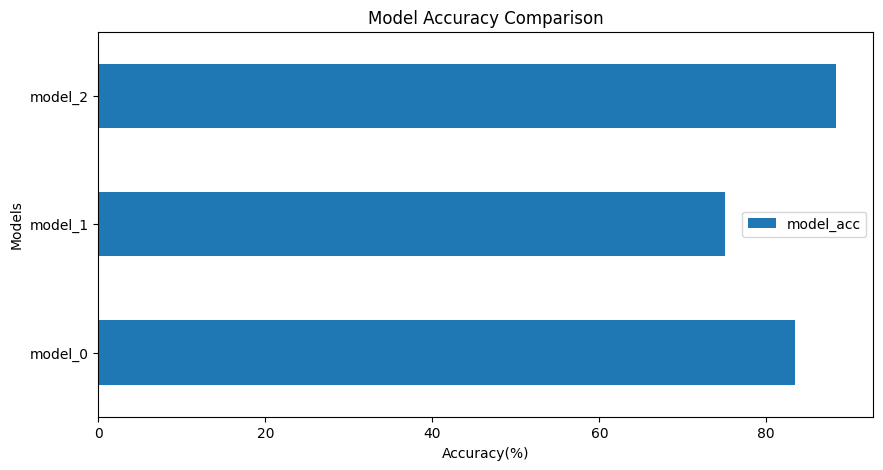

In [51]:
# Visualize the results of the three models
compare_df[["model_acc"]].plot(kind="barh", figsize=(10, 5), title="Model Accuracy Comparison")
plt.xlabel("Accuracy(%)")
plt.ylabel("Models")
plt.show()


## Make a evaluate random predictions with best model

In [52]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device): # type: ignore
    """Makes predictions on a list of images using a trained PyTorch model."""
    model.to(device) # Send the model to the target device
    model.eval() # Put the model in evaluation mode
    pred_probs = []
    with torch.inference_mode(): # Turn on inference mode (turns off gradients)
        for sample in data:
            # Prepare the sample
            sample = sample.to(device).unsqueeze(0) # Add a batch dimension and send to device
            
            # Make a prediction
            pred_logit = model(sample) # Get raw logits from the model
            
            # Convert logits to prediction probabilities
            pred_prob = torch.softmax(pred_logit, dim=1) # Apply softmax to get probabilities
            
            pred_probs.append(pred_prob.cpu()) # Move to CPU and append to list
    
    return torch.stack(pred_probs) # Concatenate all prediction probabilities into a single tensor

In [53]:
import random
# random.seed(42)

test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), 9): # type: ignore
    test_samples.append(sample)
    test_labels.append(label)

# View the shape of the test samples and labels
print(f"Test samples shape: {test_samples[0].shape}")



Test samples shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Coat')

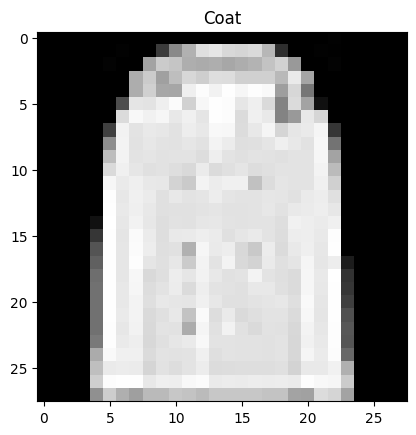

In [54]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(f"{class_names[test_labels[0]]}")

In [59]:
# Make predictions on the test samples using model_2
pred_probs = make_predictions(model=model_2, data=test_samples, device=device) # type: ignore
pred_probs[:2]


tensor([[[7.2156e-02, 1.6169e-03, 1.2948e-01, 4.9586e-02, 5.6513e-01,
          4.3475e-05, 1.5869e-01, 6.9639e-05, 2.3111e-02, 1.1696e-04]],

        [[1.1246e-05, 9.9977e-01, 1.0188e-06, 1.5717e-04, 5.7059e-05,
          8.3105e-07, 7.7291e-07, 1.0294e-07, 5.3359e-07, 3.5130e-08]]])

In [64]:
# Convert prediction probabilities to predicted labels
pred_labels = pred_probs.argmax(dim=-1).squeeze()
print(f"Predicted labels: {pred_labels}")
print(f"True labels: {torch.tensor(test_labels)}")

Predicted labels: tensor([4, 1, 4, 4, 7, 4, 6, 5, 7])
True labels: tensor([4, 1, 6, 4, 7, 4, 0, 5, 7])


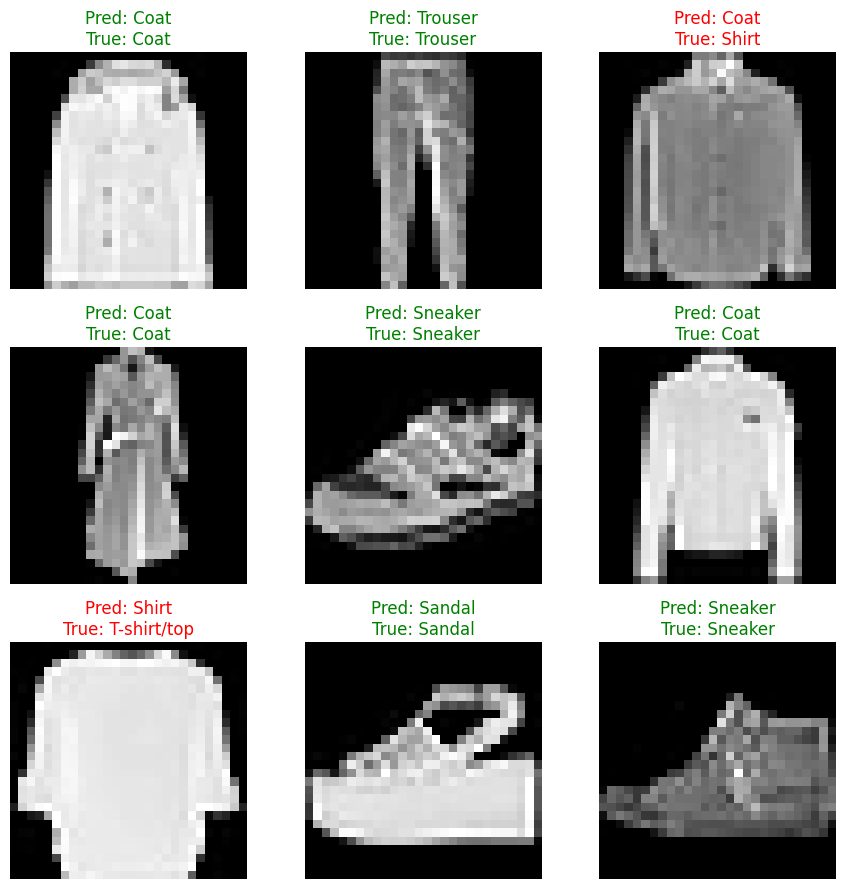

In [65]:
# Plot the test samples and their predicted labels
plt.figure(figsize=(9, 9))
nrows, ncols = 3, 3
for i, sample in enumerate(test_samples):
    plt.subplot(3, 3, i + 1) # Create a subplot for each sample
    plt.imshow(sample.squeeze(), cmap="gray") # Show the sample image
    pred_label = class_names[pred_labels[i]]
    true_label = class_names[test_labels[i]]
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}") # Add a title with the predicted and true labels
    if pred_label == true_label:
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color="green") # If the prediction is correct, make the title green
    else:
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color="red") # If the prediction is incorrect, make the title red  
    plt.axis(False) # Turn off the axis
plt.tight_layout()


## 10. Making a confusion matrix for further prediction evaluate

混淆矩阵（Confusion Matrix） 是分类模型常用的评价方法，通过统计模型预测结果与真实标签之间的对应关系来评估模型性能。

在二分类任务中，混淆矩阵包含四种情况：TP（真正例）、TN（真负例）、FP（假正例） 和 FN（假负例）。

基于混淆矩阵可以计算多种评价指标，如准确率（Accuracy）、精确率（Precision）、召回率（Recall） 和 F1-score。

相比仅使用准确率，混淆矩阵能够更全面地反映模型的分类效果，尤其适用于分析类别不平衡问题以及模型容易混淆的类别，是评价分类模型性能的重要工具。

1. Make Predictions with our trained model on test dataset.

2. Make confusion matrix `torchmetrix.ConfuseMatrix`.

3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [66]:
# import tqdm.auto
from tqdm.auto import tqdm

# 1. Make predictions on the test samples using model_2
y_preds = []
model_2.eval() # Put the model in evaluation mode
with torch.inference_mode(): # Turn on inference mode (turns off gradients)
    for X, y in tqdm(test_dataloader):
        X, y = X.to(device), y.to(device)
        y_logits = model_2(X) # Get raw logits from the model
        y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1) # Apply softmax to get prediction probabilities
        y_preds.append(y_pred.cpu())

# Concatenate all predictions into a single tensor
print(f"Number of batches predicted: {len(y_preds)}")  
y_preds_tensor = torch.cat(y_preds)
print(f"Shape of predictions tensor: {y_preds_tensor.shape}")

  0%|          | 0/313 [00:00<?, ?it/s]

Number of batches predicted: 313
Shape of predictions tensor: torch.Size([10000])


In [67]:
# See if requered packages are installed and import them if not
try:
    import torchmetrics, mlxtend
    print("torchmetrics and mlxtend are already installed.")
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchmetrics", "mlxtend"])
    import torchmetrics, mlxtend
    print("torchmetrics and mlxtend have been installed.")

# Check the versions of torchmetrics and mlxtend
print(f"torchmetrics version: {torchmetrics.__version__}")
print(f"mlxtend version: {mlxtend.__version__}")

torchmetrics and mlxtend have been installed.
torchmetrics version: 1.9.0
mlxtend version: 0.23.4


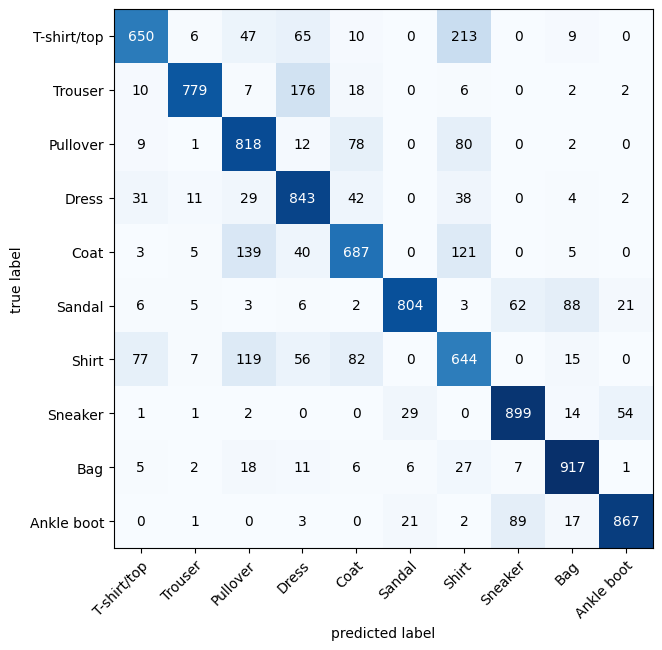

In [75]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Set up the confusion matrix
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass").to(device)
confmat_tensor = confmat(
    preds=y_preds_tensor.to(device),
    target=test_data.targets.to(device))
confmat_tensor

# Plot the confusion matrix
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.cpu().numpy(),
                                class_names=class_names,
                                figsize=(10, 7))


## Save and load best performing model

In [78]:
from pathlib import Path
# Create a directory to save the model if it doesn't exist
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

model_name = "fashion_mnist_model_2.pth"
model_path = model_dir / model_name

print(f"Model will be saved to: {model_path}")
torch.save(obj=model_2.state_dict(), f=model_path)

model_2.state_dict()


Model will be saved to: models/fashion_mnist_model_2.pth


OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.3182,  0.3230, -0.4629],
                        [ 0.1016,  0.2312,  0.0332],
                        [-0.4992,  0.1790,  0.4808]]],
              
              
                      [[[-0.3464,  0.5508, -0.1546],
                        [ 0.1910,  0.4170,  0.1271],
                        [-0.1563,  0.3736,  0.1313]]],
              
              
                      [[[-0.3401, -0.1098, -0.0030],
                        [-0.6087, -0.6370,  0.1644],
                        [-0.7663, -0.6539, -0.1468]]],
              
              
                      [[[-0.7351, -1.1084, -0.4939],
                        [ 0.3387, -0.7706,  0.2117],
                        [ 0.3356, -0.1175,  0.3620]]],
              
              
                      [[[ 0.0426,  0.3141, -0.1925],
                        [-0.1246,  0.2230, -0.2201],
                        [-0.0247,  0.2639,  0.1508]]],
              
              
      

In [79]:
# Create a new instance of the model and load the saved state_dict
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                        hidden_units=10,
                                        output_shape=len(class_names)).to(device)
loaded_model_2.load_state_dict(torch.load(f=model_path))

loaded_model_2.to(device) # Send the model to the target device

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [81]:
# Evaluate the loaded model on the test dataset
loaded_model_2_results = evaluate_model(model=loaded_model_2,
                                        data_loader=test_dataloader,
                                        loss_fn=loss_fn,
                                        accuracy_fn=accuracy_fn)

torch.isclose(torch.tensor(model_2_results["model_loss"]), torch.tensor(loaded_model_2_results["model_loss"])) and \
torch.isclose(torch.tensor(model_2_results["model_acc"]), torch.tensor(loaded_model_2_results["model_acc"]))

tensor(True)